In [4]:
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [5]:
samples_gdf = gpd.read_parquet('../data/cpb_lc/samples.par')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.422..1.3876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.2976..1.2352].


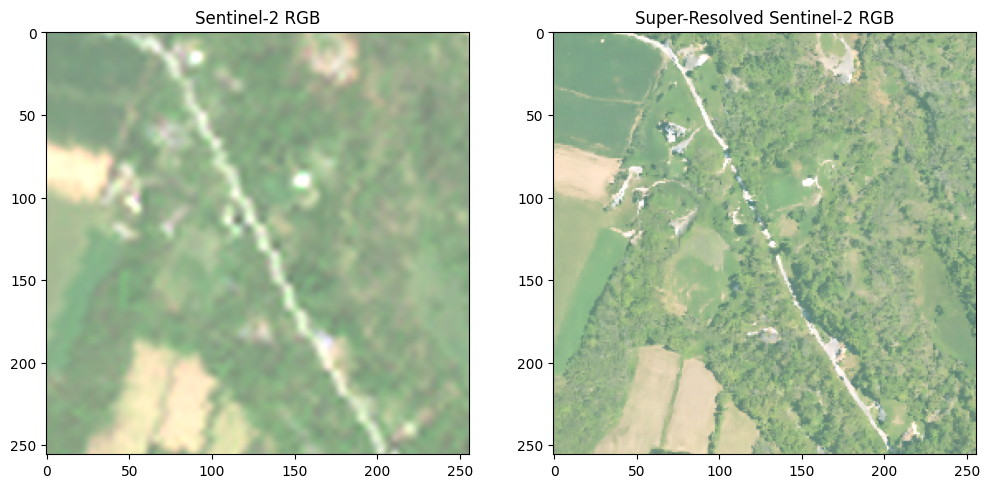

In [34]:
import numpy as np
def colorize_labels(label_array, colormap):
    """Convert a 2D array of labels to a 3D RGB array using the provided colormap."""
    h, w = label_array.shape
    rgb_array = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in colormap.items():
        rgb_array[label_array == label] = color
    return rgb_array

row = samples_gdf.iloc[3]
base_path = '../data/cpb_lc/'
# lc_path = os.path.join(base_path, row['lc_path'].replace('./', ''))
# naip_path = os.path.join(base_path, row['naip_path'].replace('./', ''))
s2_path = os.path.join(base_path, row['s2_path'].replace('./', ''))
s2sr_path = os.path.join(base_path, row['s2sr_path'].replace('./', ''))

# with rio.open(lc_path) as lc_src:
#     lc_data = lc_src.read(1)
#     lc_colormap = lc_src.colormap(1)

# lc_rgb = colorize_labels(lc_data, lc_colormap)
# plt.imshow(lc_rgb)

with rio.open(s2_path) as s2_src:
    s2_data = s2_src.read()

with rio.open(s2sr_path) as s2sr_src:
    s2sr_data = s2sr_src.read()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(np.transpose(s2_data[:3, :, :], (1, 2, 0)) / 2500)
ax[0].set_title('Sentinel-2 RGB')
ax[1].imshow(np.transpose(s2sr_data[:3, :, :], (1, 2, 0)) / 2500)
ax[1].set_title('Super-Resolved Sentinel-2 RGB')
plt.show()

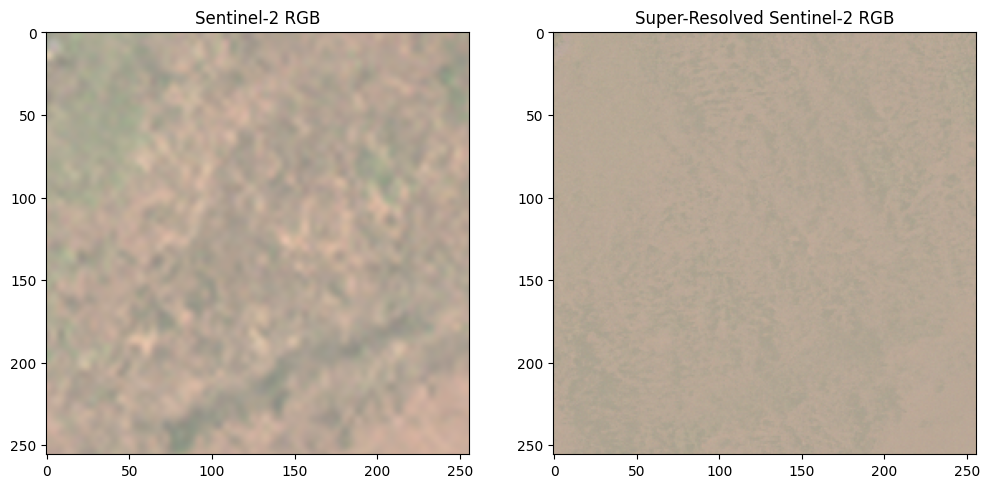

In [ ]:
# with rio.open(s2_path) as s2_src:
#     s2_data = s2_src.read()

# with rio.open(s2sr_path) as s2sr_src:
#     s2sr_data = s2sr_src.read()

# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# ax[0].imshow(np.transpose(s2_data[:3, :, :], (1, 2, 0)) / 2500)
# ax[0].set_title('Sentinel-2 RGB')
# ax[1].imshow(np.transpose(s2sr_data[:3, :, :], (1, 2, 0)) / 2500)
# ax[1].set_title('Super-Resolved Sentinel-2 RGB')
# plt.show()